In [1]:
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm


In [2]:
def make_df(file_path):
    df = pd.DataFrame()

    tritrig_file = uproot.open(file_path)

    # Open ROOT tree
    tree = tritrig_file['preselection']

    # Access branches
    B_vertex = tree['vertex.']
    B_ele = tree['ele.']
    B_pos = tree['pos.']


    # Get vertex positions
    vertex_pos = B_vertex['vertex.pos_'].array()
    #df['vertex_pos_x'] = np.array(vertex_pos['fX'])
    #df['vertex_pos_y'] = np.array(vertex_pos['fY'])
    #df['vertex_pos_z'] = np.array(vertex_pos['fZ'])

    # Get arrays of the electron and positron energies as measured with Ecal
    df['ele_E_Ecal'] = np.array(B_ele['ele.energy_'])
    df['pos_E_Ecal'] = np.array(B_pos['pos.energy_'])
    # Get number of hits in Ecal clusters
    #df['ele_Ecal_nhits'] = np.array(tree['ele_clu_nhits'])
    #df['pos_Ecal_nhits'] = np.array(tree['pos_clu_nhits'])
    # Get Ecal cluster positions
    df['ele_Ecal_x']= np.array(B_ele['ele.cluster_.x_'])
    df['ele_Ecal_y']= np.array(B_ele['ele.cluster_.y_'])
    df['ele_Ecal_z']= np.array(B_ele['ele.cluster_.z_'])
    df['pos_Ecal_x']= np.array(B_pos['pos.cluster_.x_'])
    df['pos_Ecal_y']= np.array(B_pos['pos.cluster_.y_'])
    df['pos_Ecal_z']= np.array(B_pos['pos.cluster_.z_'])

    # Get number of hits on track
    #df['ele_trk_nhits'] = np.array(B_ele[ 'ele.track_/ele.track_.n_hits_'])
    #df['pos_trk_nhits'] = np.array(B_pos[ 'pos.track_/pos.track_.n_hits_'])
    # Get Electron and Positron momenta
    arr = B_vertex['vertex.p1_'].array()
    df['ele_Px'] = np.array(arr['fX'])
    df['ele_Py'] = np.array(arr['fY'])
    df['ele_Pz'] = np.array(arr['fZ'])
    arr = B_vertex['vertex.p2_'].array()
    df['pos_Px'] = np.array(arr['fX'])
    df['pos_Py'] = np.array(arr['fY'])
    df['pos_Pz'] = np.array(arr['fZ'])
    # Collect track parameters for electrons and positrons
    #df['ele_phi0'] = -np.array(B_ele['ele.track_/ele.track_.phi0_'])
    #df['ele_dp'] = np.array(B_ele['ele.track_/ele.track_.d0_'])
    #df['ele_kappa_o_alpha'] = -np.array(B_ele['ele.track_/ele.track_.omega_'])
    #df['ele_dz'] = -np.array(B_ele['ele.track_/ele.track_.z0_'])
    #df['ele_tan_lambda'] = -np.array(B_ele['ele.track_/ele.track_.tan_lambda_'])
    #df['pos_phi0'] = -np.array(B_pos['pos.track_/pos.track_.phi0_'])
    #df['pos_dp'] = np.array(B_pos['pos.track_/pos.track_.d0_'])
    #df['pos_kappa_o_alpha'] = -np.array(B_pos['pos.track_/pos.track_.omega_'])
    #df['pos_dz'] = -np.array(B_pos['pos.track_/pos.track_.z0_'])
    #df['pos_tan_lambda'] = -np.array(B_pos['pos.track_/pos.track_.tan_lambda_'])

    return df


In [4]:
# Create dataframes 
df_tritrig = make_df('/Users/mghrear/data/HPS_mc/2021_v8_pass4/tritrig/tritrig_pulser_hadd_500files.root')
df_phiKK = make_df('/Users/mghrear/data/HPS_mc/2021_v8_pass4/phiKK/2021_v8_pass4_phiKK_data_5.root')
df_wab = make_df('/Users/mghrear/data/HPS_mc/2021_v8_pass4/wab/wab_pulser_hadd_1000files.root')
df_data = make_df('/Users/mghrear/data/HPS_data/2021_v8_pass4_run14269/2021_v8_pass4_run14269.root')






/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_89839/2821622770.py:40: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  df['ele_Px'] = np.array(arr['fX'])
/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_89839/2821622770.py:41: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  df['ele_Py'] = np.array(arr['fY'])
/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_89839/2821622770.py:42: DeprecationWarning: __array__ implementation doesn't accept a copy 

In [5]:
df_tritrig.to_pickle('/Users/mghrear/data/ML_data/patch/BDT_2021_tritrig_limited.pk')
df_phiKK.to_pickle('/Users/mghrear/data/ML_data/patch/BDT_2021_phiKK_limited.pk')
df_wab.to_pickle('/Users/mghrear/data/ML_data/patch/BDT_2021_wab_limited.pk')
df_data.to_pickle('/Users/mghrear/data/ML_data/patch/BDT_2021_data_limited.pk')

# Compare these attributes in data vs. monte carlo 

In [33]:
df_tritrig_study = df_tritrig.copy()
df_phiKK_study = df_phiKK.copy()
df_wab_study = df_wab.copy()
df_data_study = df_data.copy()

In [54]:
df_wab_study

,ele_E_Ecal,pos_E_Ecal,ele_Ecal_x,ele_Ecal_y,ele_Ecal_z,pos_Ecal_x,pos_Ecal_y,pos_Ecal_z,ele_Px,ele_Py,ele_Pz,pos_Px,pos_Py,pos_Pz,e_Ptot,p_Ptot,e_SVT_E_K,p_SVT_E_K,M,Ptot
0,0.000000,1.537048,-9999.000000,-9999.000000,-9999.000000,164.303467,28.158854,1449.173706,0.086627,-0.038150,1.607146,0.027394,0.026721,1.668634,1.609931,1.669072,1.683922,1.740551,0.991544,3.279003
1,1.403944,2.096279,-126.794052,59.098911,1449.727295,155.629425,-30.934160,1449.062744,0.043688,0.060889,1.408126,0.052937,-0.046832,2.013051,1.410119,2.014291,1.494039,2.073906,1.008090,3.424410
2,1.539981,1.964746,-134.114212,50.821701,1449.727295,153.728516,-28.305363,1449.062744,0.036611,0.054802,1.410525,0.043153,-0.044056,1.994864,1.412064,1.995817,1.495875,2.055967,1.006197,3.407880
3,0.000000,1.247574,-9999.000000,-9999.000000,-9999.000000,303.685974,58.486938,1450.375610,0.089211,-0.054778,2.376716,0.060844,0.046946,1.131235,2.379021,1.133842,2.429703,1.236655,1.055405,3.512863
4,1.263342,1.874052,-142.227661,59.897232,1449.836548,155.805069,-27.108393,1449.062744,0.044491,0.050773,1.218114,0.043716,-0.038067,2.001948,1.219983,2.002787,1.316084,2.062734,1.019642,3.222770
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6114,1.315864,1.057268,-153.009857,-47.322266,1449.945435,205.677505,28.257080,1449.504517,0.036791,-0.039709,1.243179,0.021799,0.020919,1.354192,1.244357,1.354529,1.338709,1.441688,0.990196,2.598886
6115,0.000000,1.011788,-9999.000000,-9999.000000,-9999.000000,299.620636,-48.255878,1450.375610,0.067828,0.048965,2.694097,0.027150,-0.034061,0.965067,2.695396,0.966049,2.740232,1.084882,1.110304,3.661445
6116,2.095780,0.928048,-102.499123,37.599007,1449.396118,219.850677,-47.845818,1449.836548,0.009351,0.054880,2.166435,0.052332,-0.048204,1.483215,2.167150,1.484920,2.222669,1.564834,1.010636,3.652070
6117,0.961364,1.767367,-227.933151,-79.890999,1450.697144,165.945984,28.145844,1449.173706,0.021436,-0.056781,0.960270,0.042728,0.034841,1.832367,0.962186,1.833196,1.081443,1.898506,1.037631,2.795382


In [55]:
df_wab_study[0:12360]

,ele_E_Ecal,pos_E_Ecal,ele_Ecal_x,ele_Ecal_y,ele_Ecal_z,pos_Ecal_x,pos_Ecal_y,pos_Ecal_z,ele_Px,ele_Py,ele_Pz,pos_Px,pos_Py,pos_Pz,e_Ptot,p_Ptot,e_SVT_E_K,p_SVT_E_K,M,Ptot
0,0.000000,1.537048,-9999.000000,-9999.000000,-9999.000000,164.303467,28.158854,1449.173706,0.086627,-0.038150,1.607146,0.027394,0.026721,1.668634,1.609931,1.669072,1.683922,1.740551,0.991544,3.279003
1,1.403944,2.096279,-126.794052,59.098911,1449.727295,155.629425,-30.934160,1449.062744,0.043688,0.060889,1.408126,0.052937,-0.046832,2.013051,1.410119,2.014291,1.494039,2.073906,1.008090,3.424410
2,1.539981,1.964746,-134.114212,50.821701,1449.727295,153.728516,-28.305363,1449.062744,0.036611,0.054802,1.410525,0.043153,-0.044056,1.994864,1.412064,1.995817,1.495875,2.055967,1.006197,3.407880
3,0.000000,1.247574,-9999.000000,-9999.000000,-9999.000000,303.685974,58.486938,1450.375610,0.089211,-0.054778,2.376716,0.060844,0.046946,1.131235,2.379021,1.133842,2.429703,1.236655,1.055405,3.512863
4,1.263342,1.874052,-142.227661,59.897232,1449.836548,155.805069,-27.108393,1449.062744,0.044491,0.050773,1.218114,0.043716,-0.038067,2.001948,1.219983,2.002787,1.316084,2.062734,1.019642,3.222770
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6114,1.315864,1.057268,-153.009857,-47.322266,1449.945435,205.677505,28.257080,1449.504517,0.036791,-0.039709,1.243179,0.021799,0.020919,1.354192,1.244357,1.354529,1.338709,1.441688,0.990196,2.598886
6115,0.000000,1.011788,-9999.000000,-9999.000000,-9999.000000,299.620636,-48.255878,1450.375610,0.067828,0.048965,2.694097,0.027150,-0.034061,0.965067,2.695396,0.966049,2.740232,1.084882,1.110304,3.661445
6116,2.095780,0.928048,-102.499123,37.599007,1449.396118,219.850677,-47.845818,1449.836548,0.009351,0.054880,2.166435,0.052332,-0.048204,1.483215,2.167150,1.484920,2.222669,1.564834,1.010636,3.652070
6117,0.961364,1.767367,-227.933151,-79.890999,1450.697144,165.945984,28.145844,1449.173706,0.021436,-0.056781,0.960270,0.042728,0.034841,1.832367,0.962186,1.833196,1.081443,1.898506,1.037631,2.795382


In [ ]:
# Calculate invariant mass and add to dataframe
m_K = 0.493677

def calculate_invariant_mass_Ptot(df):
    # Calculate total electron momentum
    df['e_Ptot'] = np.sqrt(df['ele_Px']**2 + df['ele_Py']**2 + df['ele_Pz']**2)
    # Calculate total positron momentum
    df['p_Ptot'] = np.sqrt(df['pos_Px']**2 + df['pos_Py']**2 + df['pos_Pz']**2)
    df['e_SVT_E_K'] = m_K / np.sqrt ( 1 - ( df.e_Ptot**2 / (df.e_Ptot**2  + m_K**2) ) )
    df['p_SVT_E_K'] = m_K / np.sqrt ( 1 - ( df.p_Ptot**2 / (df.p_Ptot**2  + m_K**2) ) )
    df['M'] = np.sqrt((df.e_SVT_E_K+df.p_SVT_E_K)**2 - (df.ele_Px+df.pos_Px)**2 - (df.ele_Py+df.pos_Py)**2 - (df.ele_Pz+df.pos_Pz)**2)
    df['Ptot'] = df.e_Ptot + df.p_Ptot

    return df

df_tritrig_study = calculate_invariant_mass_Ptot(df_tritrig_study)
df_phiKK_study = calculate_invariant_mass_Ptot(df_phiKK_study)
df_wab_study = calculate_invariant_mass_Ptot(df_wab_study)
df_data_study = calculate_invariant_mass_Ptot(df_data_study)

df_combined_study = pd.concat([df_tritrig_study[0:25662], df_phiKK_study[0:1]], ignore_index=True, sort=False)   

Text(0.5, 1.0, 'Invariant Mass Distribution for Combined MC Samples')

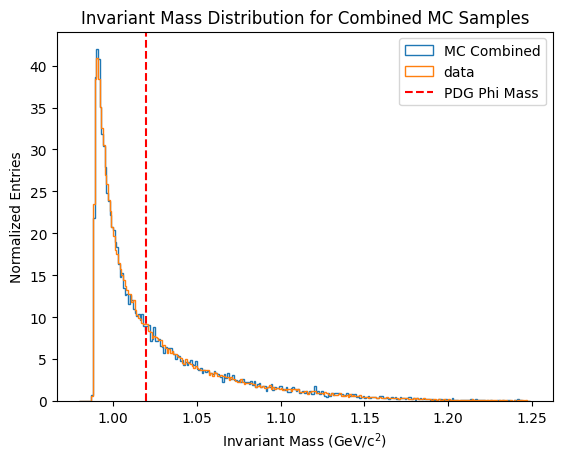

In [36]:
plt.hist(df_combined_study['M'], bins=np.arange(.980,1.250,0.001), range=(0,1.5), histtype='step', label='MC Combined', density=True)
plt.hist(df_data_study['M'], bins=np.arange(.980,1.250,0.001), range=(0,1.5), histtype='step', label='data', density=True)
#plt.hist(df_phiKK_study['M'], bins=np.arange(.980,1.250,0.001), range=(0,1.5), histtype='step', label='PhiKK', density=True)
plt.axvline(x=1.019461, color='r', linestyle='--', label='PDG Phi Mass')

plt.legend()
plt.xlabel('Invariant Mass (GeV/c$^2$)')
plt.ylabel('Normalized Entries')
plt.title('Invariant Mass Distribution for Combined MC Samples')

Text(0, 0.5, 'Normalized Entries')

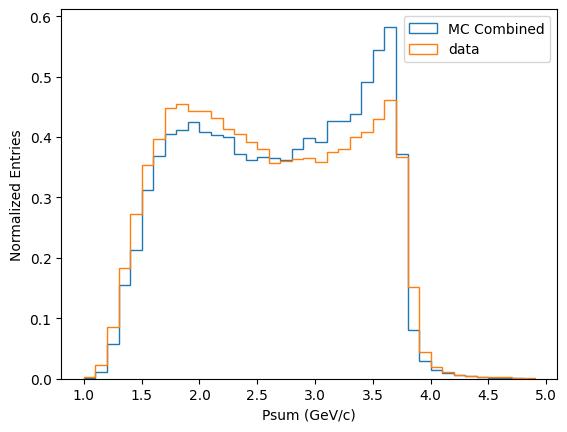

In [38]:
plt.hist(df_combined_study['Ptot'], bins=np.arange(1,5.0,0.1), histtype='step', label='MC Combined', density=True)
plt.hist(df_data_study['Ptot'], bins=np.arange(1,5.0,0.1), histtype='step', label='data', density=True)
#plt.hist(df_phiKK_study['Ptot'], bins=np.arange(1,5.0,0.1), histtype='step', label='PhiKK', density=True)


plt.legend()
plt.xlabel('Psum (GeV/c)')
plt.ylabel('Normalized Entries')


Text(0, 0.5, 'Normalized Entries')

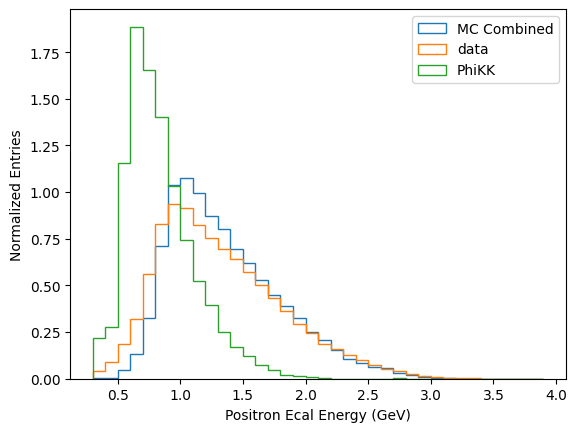

In [40]:
plt.hist(df_combined_study['pos_E_Ecal'], bins=np.arange(.3,4,0.1), range=(0,1.5), histtype='step', label='MC Combined', density=True)
plt.hist(df_data_study['pos_E_Ecal'], bins=np.arange(.3,4,0.1), range=(0,1.5), histtype='step', label='data', density=True)
plt.hist(df_phiKK_study['pos_E_Ecal'], bins=np.arange(.3,4,0.1), range=(0,1.5), histtype='step', label='PhiKK', density=True)


plt.legend()
plt.xlabel('Positron Ecal Energy (GeV)')
plt.ylabel('Normalized Entries')


Text(0, 0.5, 'Normalized Entries')

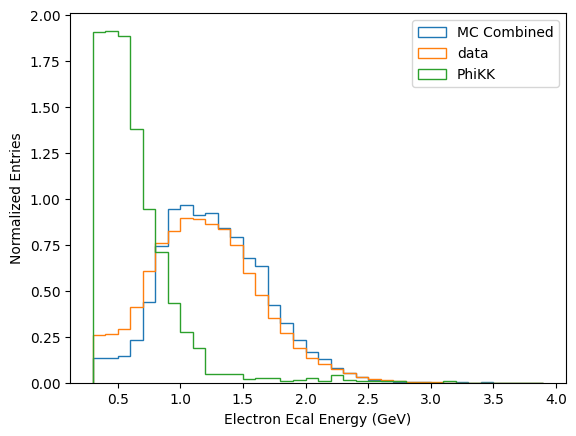

In [41]:
plt.hist(df_combined_study['ele_E_Ecal'], bins=np.arange(.3,4,0.1), range=(0,1.5), histtype='step', label='MC Combined', density=True)
plt.hist(df_data_study['ele_E_Ecal'], bins=np.arange(.3,4,0.1), range=(0,1.5), histtype='step', label='data', density=True)
plt.hist(df_phiKK_study['ele_E_Ecal'], bins=np.arange(.3,4,0.1), range=(0,1.5), histtype='step', label='PhiKK', density=True)


plt.legend()
plt.xlabel('Electron Ecal Energy (GeV)')
plt.ylabel('Normalized Entries')


Text(0, 0.5, 'Normalized Entries')

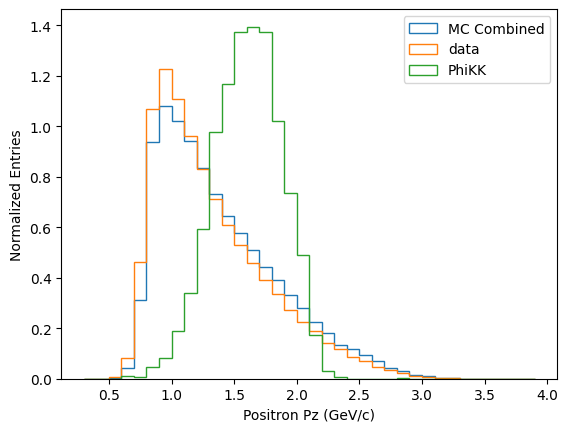

In [42]:
plt.hist(df_combined_study['pos_Pz'], bins=np.arange(.3,4,0.1), range=(0,1.5), histtype='step', label='MC Combined', density=True)
plt.hist(df_data_study['pos_Pz'], bins=np.arange(.3,4,0.1), range=(0,1.5), histtype='step', label='data', density=True)
plt.hist(df_phiKK_study['pos_Pz'], bins=np.arange(.3,4,0.1), range=(0,1.5), histtype='step', label='PhiKK', density=True)


plt.legend()
plt.xlabel('Positron Pz (GeV/c)')
plt.ylabel('Normalized Entries')


Text(0, 0.5, 'Normalized Entries')

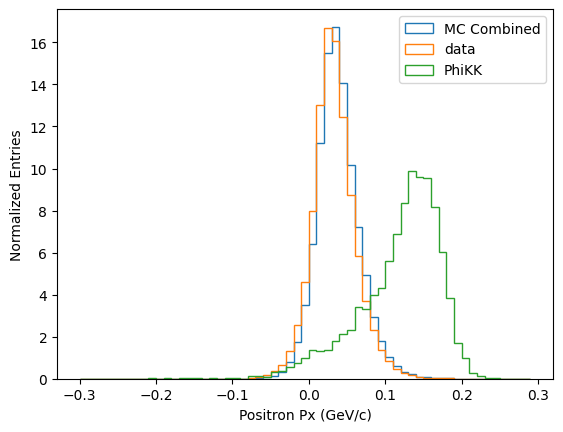

In [43]:
plt.hist(df_combined_study['pos_Px'], bins=np.arange(-.3,.3,0.01), range=(0,1.5), histtype='step', label='MC Combined', density=True)
plt.hist(df_data_study['pos_Px'], bins=np.arange(-.3,.3,0.01), range=(0,1.5), histtype='step', label='data', density=True)
plt.hist(df_phiKK_study['pos_Px'], bins=np.arange(-.3,.3,0.01), range=(0,1.5), histtype='step', label='PhiKK', density=True)


plt.legend()
plt.xlabel('Positron Px (GeV/c)')
plt.ylabel('Normalized Entries')


Text(0, 0.5, 'Normalized Entries')

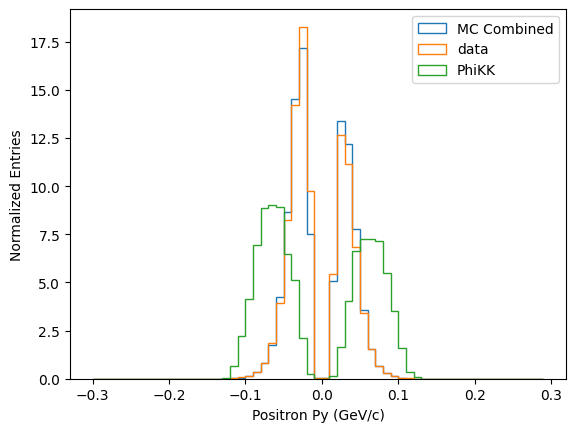

In [44]:
plt.hist(df_combined_study['pos_Py'], bins=np.arange(-.3,.3,0.01), range=(0,1.5), histtype='step', label='MC Combined', density=True)
plt.hist(df_data_study['pos_Py'], bins=np.arange(-.3,.3,0.01), range=(0,1.5), histtype='step', label='data', density=True)
plt.hist(df_phiKK_study['pos_Py'], bins=np.arange(-.3,.3,0.01), range=(0,1.5), histtype='step', label='PhiKK', density=True)


plt.legend()
plt.xlabel('Positron Py (GeV/c)')
plt.ylabel('Normalized Entries')


Text(0, 0.5, 'Normalized Entries')

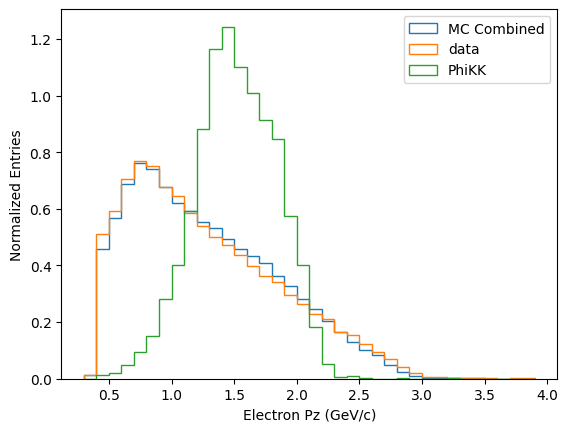

In [45]:
plt.hist(df_combined_study['ele_Pz'], bins=np.arange(.3,4,0.1), range=(0,1.5), histtype='step', label='MC Combined', density=True)
plt.hist(df_data_study['ele_Pz'], bins=np.arange(.3,4,0.1), range=(0,1.5), histtype='step', label='data', density=True)
plt.hist(df_phiKK_study['ele_Pz'], bins=np.arange(.3,4,0.1), range=(0,1.5), histtype='step', label='PhiKK', density=True)


plt.legend()
plt.xlabel('Electron Pz (GeV/c)')
plt.ylabel('Normalized Entries')


Text(0, 0.5, 'Normalized Entries')

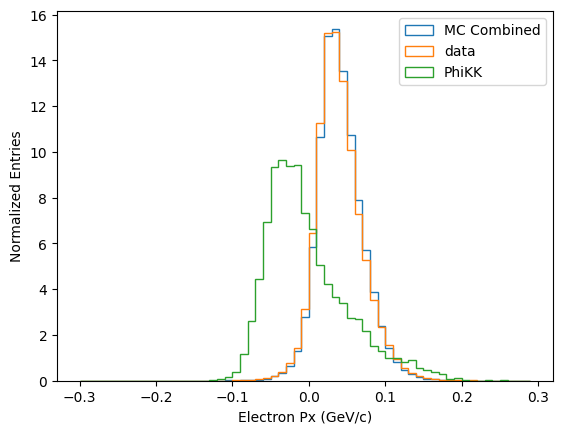

In [46]:
plt.hist(df_combined_study['ele_Px'], bins=np.arange(-.3,.3,0.01), range=(0,1.5), histtype='step', label='MC Combined', density=True)
plt.hist(df_data_study['ele_Px'], bins=np.arange(-.3,.3,0.01), range=(0,1.5), histtype='step', label='data', density=True)
plt.hist(df_phiKK_study['ele_Px'], bins=np.arange(-.3,.3,0.01), range=(0,1.5), histtype='step', label='PhiKK', density=True)


plt.legend()
plt.xlabel('Electron Px (GeV/c)')
plt.ylabel('Normalized Entries')


Text(0, 0.5, 'Normalized Entries')

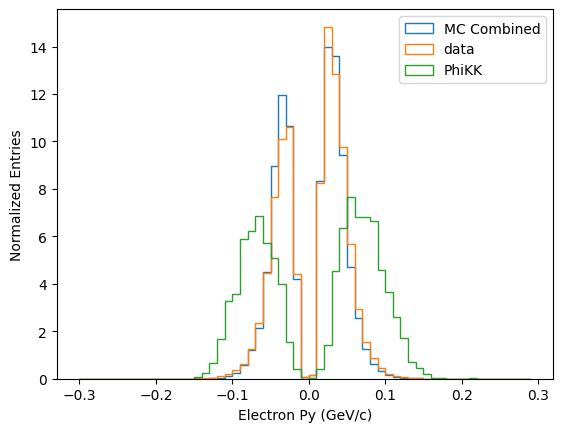

In [47]:
plt.hist(df_combined_study['ele_Py'], bins=np.arange(-.3,.3,0.01), range=(0,1.5), histtype='step', label='MC Combined', density=True)
plt.hist(df_data_study['ele_Py'], bins=np.arange(-.3,.3,0.01), range=(0,1.5), histtype='step', label='data', density=True)
plt.hist(df_phiKK_study['ele_Py'], bins=np.arange(-.3,.3,0.01), range=(0,1.5), histtype='step', label='PhiKK', density=True)


plt.legend()
plt.xlabel('Electron Py (GeV/c)')
plt.ylabel('Normalized Entries')


Text(0, 0.5, 'Normalized Entries')

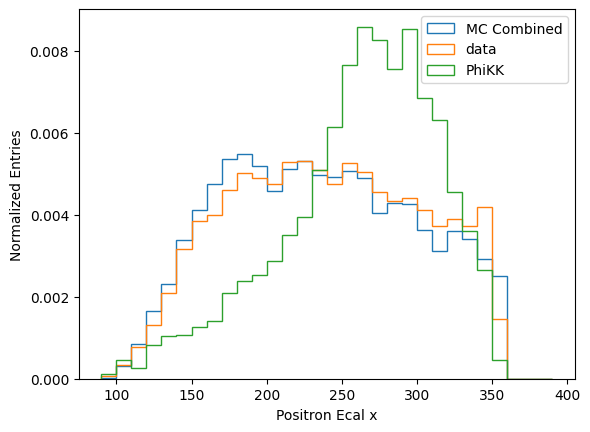

In [48]:
plt.hist(df_combined_study['pos_Ecal_x'], bins=np.arange(90,400,10), range=(0,1.5), histtype='step', label='MC Combined', density=True)
plt.hist(df_data_study['pos_Ecal_x'], bins=np.arange(90,400,10), range=(0,1.5), histtype='step', label='data', density=True)
plt.hist(df_phiKK_study['pos_Ecal_x'], bins=np.arange(90,400,10), range=(0,1.5), histtype='step', label='PhiKK', density=True)


plt.legend()
plt.xlabel('Positron Ecal x')
plt.ylabel('Normalized Entries')


Text(0, 0.5, 'Normalized Entries')

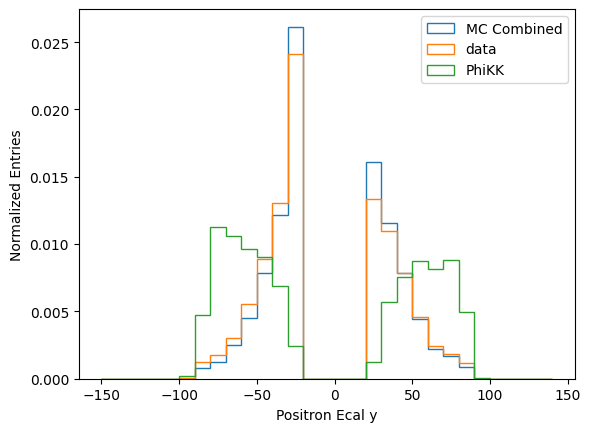

In [49]:
plt.hist(df_combined_study['pos_Ecal_y'], bins=np.arange(-150,150,10), range=(0,1.5), histtype='step', label='MC Combined', density=True)
plt.hist(df_data_study['pos_Ecal_y'], bins=np.arange(-150,150,10), range=(0,1.5), histtype='step', label='data', density=True)
plt.hist(df_phiKK_study['pos_Ecal_y'], bins=np.arange(-150,150,10), range=(0,1.5), histtype='step', label='PhiKK', density=True)


plt.legend()
plt.xlabel('Positron Ecal y')
plt.ylabel('Normalized Entries')


Text(0, 0.5, 'Normalized Entries')

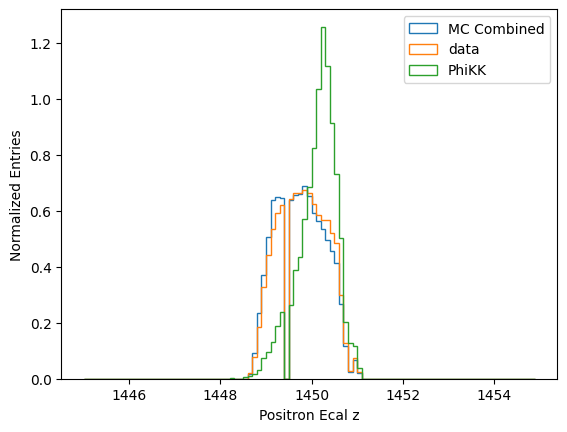

In [50]:
plt.hist(df_combined_study['pos_Ecal_z'], bins=np.arange(1445,1455,.1), range=(0,1.5), histtype='step', label='MC Combined', density=True)
plt.hist(df_data_study['pos_Ecal_z'], bins=np.arange(1445,1455,.1), range=(0,1.5), histtype='step', label='data', density=True)
plt.hist(df_phiKK_study['pos_Ecal_z'], bins=np.arange(1445,1455,.1), range=(0,1.5), histtype='step', label='PhiKK', density=True)


plt.legend()
plt.xlabel('Positron Ecal z')
plt.ylabel('Normalized Entries')


Text(0, 0.5, 'Normalized Entries')

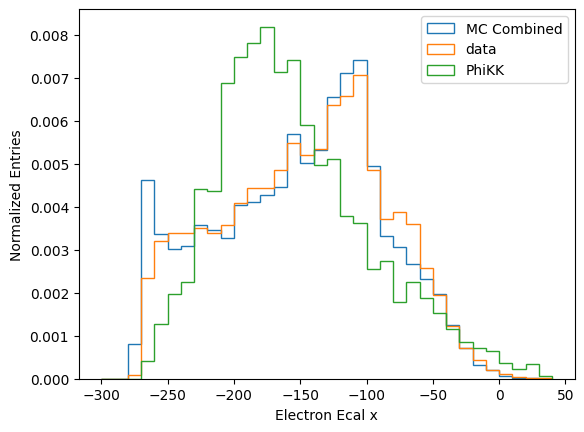

In [51]:
plt.hist(df_combined_study['ele_Ecal_x'], bins=np.arange(-300,50,10), histtype='step', label='MC Combined', density=True)
plt.hist(df_data_study['ele_Ecal_x'], bins=np.arange(-300,50,10), histtype='step', label='data', density=True)
plt.hist(df_phiKK_study['ele_Ecal_x'], bins=np.arange(-300,50,10), histtype='step', label='PhiKK', density=True)


plt.legend()
plt.xlabel('Electron Ecal x')
plt.ylabel('Normalized Entries')


Text(0, 0.5, 'Normalized Entries')

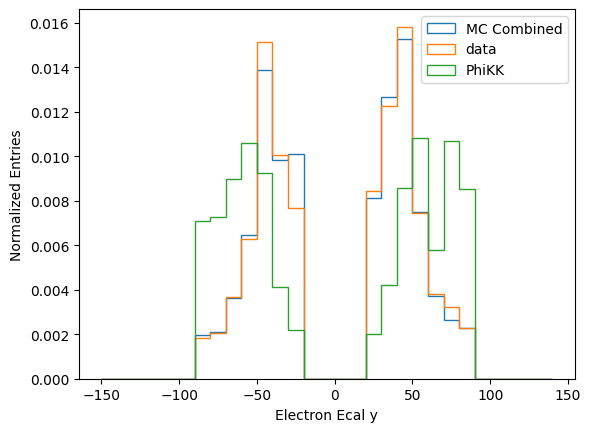

In [52]:
plt.hist(df_combined_study['ele_Ecal_y'], bins=np.arange(-150,150,10), range=(0,1.5), histtype='step', label='MC Combined', density=True)
plt.hist(df_data_study['ele_Ecal_y'], bins=np.arange(-150,150,10), range=(0,1.5), histtype='step', label='data', density=True)
plt.hist(df_phiKK_study['ele_Ecal_y'], bins=np.arange(-150,150,10), range=(0,1.5), histtype='step', label='PhiKK', density=True)


plt.legend()
plt.xlabel('Electron Ecal y')
plt.ylabel('Normalized Entries')


Text(0, 0.5, 'Normalized Entries')

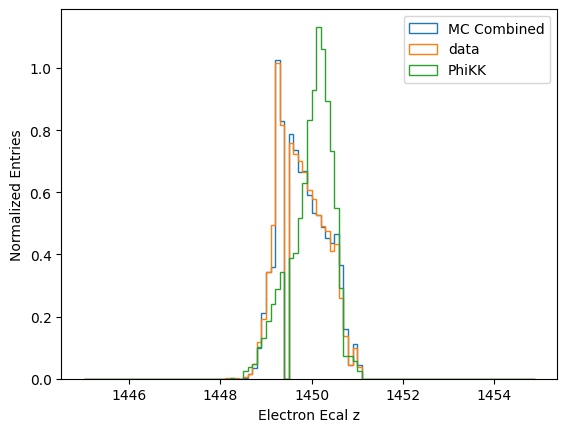

In [53]:
plt.hist(df_combined_study['ele_Ecal_z'], bins=np.arange(1445,1455,.1), range=(0,1.5), histtype='step', label='MC Combined', density=True)
plt.hist(df_data_study['ele_Ecal_z'], bins=np.arange(1445,1455,.1), range=(0,1.5), histtype='step', label='data', density=True)
plt.hist(df_phiKK_study['ele_Ecal_z'], bins=np.arange(1445,1455,.1), range=(0,1.5), histtype='step', label='PhiKK', density=True)


plt.legend()
plt.xlabel('Electron Ecal z')
plt.ylabel('Normalized Entries')
